In [1]:
# All imports you'll need for the entire notebook
import os, time, copy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
TRAIN_DIR = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Train'
TEST_DIR  = '/kaggle/input/datasets/kedarsai/bird-species-classification-220-categories/Test'

# Verify
train_classes = sorted(os.listdir(TRAIN_DIR))
test_classes  = sorted(os.listdir(TEST_DIR))

print(f"Train classes : {len(train_classes)}")
print(f"Test  classes : {len(test_classes)}")

# Count total images
train_count = sum(len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes)
test_count  = sum(len(os.listdir(os.path.join(TEST_DIR,  c))) for c in test_classes)
print(f"Train images  : {train_count}")
print(f"Test  images  : {test_count}")

Train classes : 200
Test  classes : 200
Train images  : 9414
Test  images  : 2374


Min images/class : 32  (Least_Auklet)
Max images/class : 48  (American_Crow)
Avg images/class : 47.1


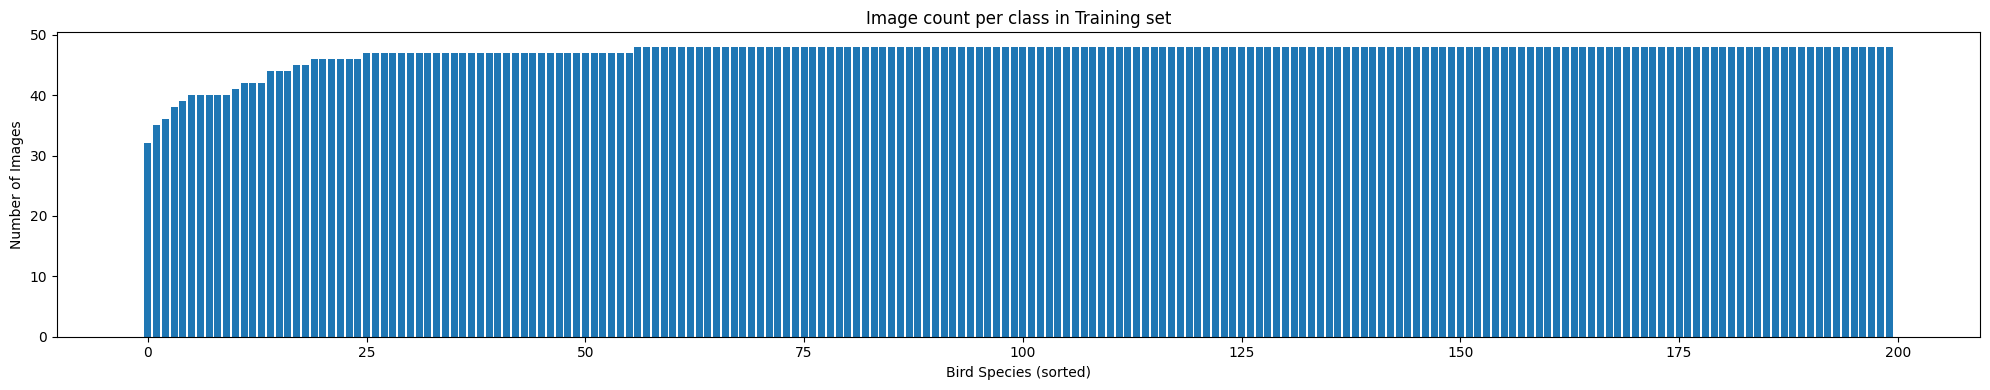

In [3]:
# Count images per class
counts = {c: len(os.listdir(os.path.join(TRAIN_DIR, c))) for c in train_classes}

print(f"Min images/class : {min(counts.values())}  ({min(counts, key=counts.get)})")
print(f"Max images/class : {max(counts.values())}  ({max(counts, key=counts.get)})")
print(f"Avg images/class : {np.mean(list(counts.values())):.1f}")

# Plot distribution
plt.figure(figsize=(20, 4))
plt.bar(range(200), sorted(counts.values()))
plt.xlabel('Bird Species (sorted)')
plt.ylabel('Number of Images')
plt.title('Image count per class in Training set')
plt.tight_layout()
plt.show()